# Data Preparation

In [186]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("default")


In [187]:
from sklearn.datasets import make_classification
X, y = make_classification(
    n_samples=100, 
    n_features=2, 
    n_informative=1,  # Changed from 1 to 2
    n_redundant=0, 
    n_classes=2,
    n_clusters_per_class=1,
    random_state=41,
    hypercube=False,
    class_sep=30
)

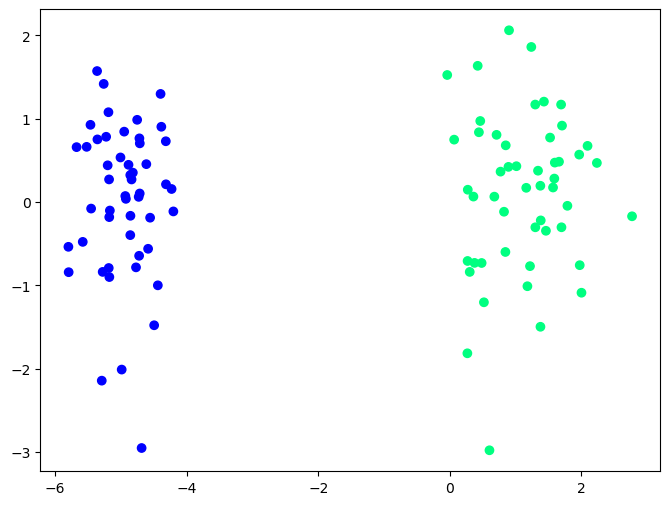

In [188]:
plt.figure(figsize=(8,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter')

# Perceptron

In [145]:
def perceptron_step(X,y):
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    for _ in range(1000):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights)) # Activation Function
        weights = weights + lr*(y[j] - y_hat)*X[j]
    return weights[0],weights[1:]

In [140]:
def perceptron(X,y):
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    for _ in range(1000): 
        j = np.random.randint(0,100)
        y_hat = sigmoid(np.dot(X[j],weights)) # Activation Function
        weights = weights + lr*(y[j] - y_hat)*X[j]
    return weights[0],weights[1:]

In [149]:
intercept_, coef_ = perceptron(X,y)

In [150]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [151]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

In [148]:
x_step = np.linspace(-3,3,100)
y_step = m*x_input + b

(-3.0, 2.0)

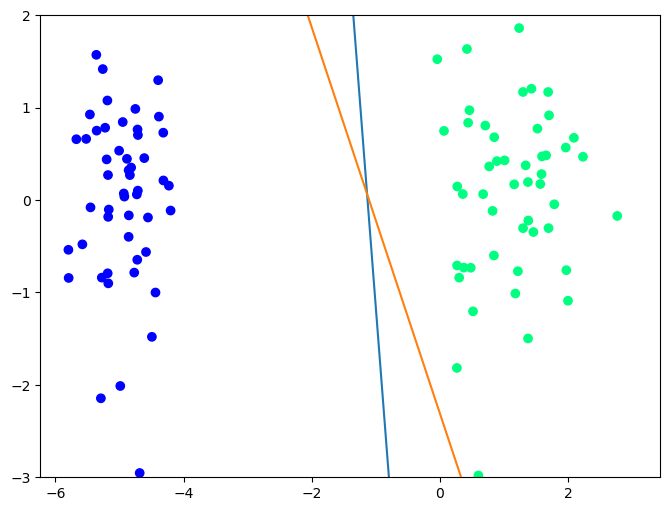

In [152]:
plt.figure(figsize=(8,6))
plt.plot(x_input,y_input)
plt.plot(x_step,y_step)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter')
plt.ylim(-3,2)

# Activations

## Step Function

In [44]:
def step(x):
    if x > 0 :
        return 1
    else:
        return 0

#### It says if prediction is true or False and Values of y_hat is always either 0 or 1

## Sigmoid Function

In [79]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

#### Sigmoid Basically gives Probabilty in y_hat, insted of it bing 1 or 0 it is chances of it bing true or wrong

# Loss Function

#### Loss function is basically a mathematical function that we can use to determine accuracy of our data and our goal is to minimize this number to get the best possible outcome from out model.

#### Funtion by which we can calculate performance of out model is sum of `-((y*log(y_hat) + (1-y)*log(1-y_hat))` of all rows in table

#### After Gradient out loss funtion Becomes `weight = weight + lr*(1/m)*(y-y_hat)`

# Final Model after Sigmoid and Loss Funtion

In [219]:
def logistic_regression(test,label):
    test = np.insert(test,0,1,axis=1)
    weights = np.ones(test.shape[1])
    lr = 0.5
    epochs = 2500
    for _ in range(epochs):
        y_hat = sigmoid(np.dot(test,weights))
        gradient = np.dot((label-y_hat),test) / test.shape[1]
        weights = weights + lr * gradient
    return weights[0],weights[1:]

In [220]:
new_intercept_, new_coef_ = logistic_regression(X,y)

In [221]:
m_lr = -(new_coef_[0]/new_coef_[1])
b_lr = -(new_intercept_/new_coef_[1])

In [222]:
x_lr = np.linspace(-3,3,100)
y_lr = m_lr*x_lr + b_lr

(-3.0, 2.0)

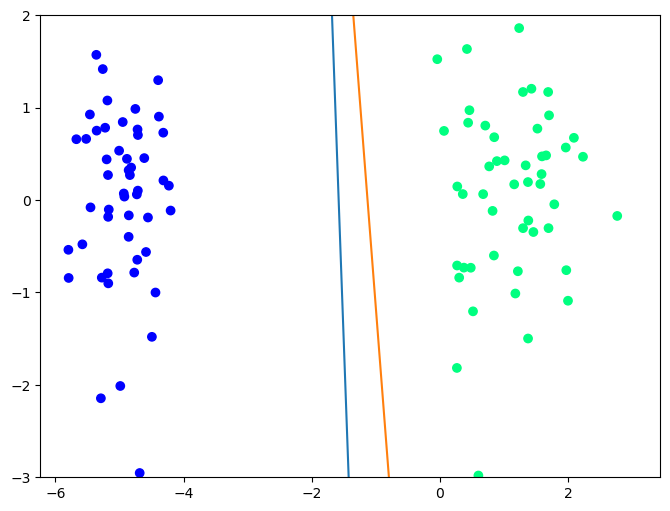

In [223]:
plt.figure(figsize=(8,6))
plt.plot(x_lr,y_lr)
plt.plot(x_input,y_input)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter')
plt.ylim(-3,2)

In [190]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
res = model.fit(X,y)
m1 = -(res.coef_[0][0] / res.coef_[0][1])
b1 = -(res.intercept_/res.coef_[0][1])
x_sk = np.linspace(-3,3,100)
y_sk = m1*x + b1

(-3.0, 2.0)

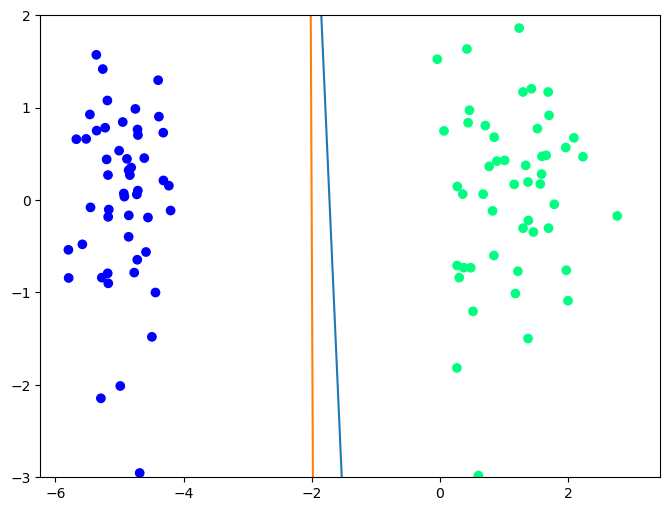

In [218]:
plt.figure(figsize=(8,6))
plt.plot(x_lr,y_lr)
plt.plot(x_sk,y_sk)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter')
plt.ylim(-3,2)

# *Commit Code on GitHub*

In [26]:
!git add . 
!git commit -m "Perceptron Done with Step" 
!git push -u origin main  

[main f80cdd0] Perceptron Done with Step
 1 file changed, 278 insertions(+), 20 deletions(-)
branch 'main' set up to track 'origin/main'.


To https://github.com/Daksh-Mistry/ML-Models.git
   005f5dc..f80cdd0  main -> main


In [46]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   Logistic Regression.ipynb

no changes added to commit (use "git add" and/or "git commit -a")
